# Modelo XGBoost: Predicción de Costos Médicos

Este notebook implementa y compara diferentes modelos de **XGBoost (Gradient Boosting)** para predecir los costos de seguros médicos (`charges`) a partir de las variables `age`, `smoker` y `bmi`.

Se entrenan tres variantes del modelo:
1. **XGBoost Base**: Configuración por defecto
2. **XGBoost Ajustado (v1)**: Hiperparámetros optimizados para mejor generalización
3. **XGBoost Ajustado (v2)**: Configuración más agresiva con mayor regularización

---

## Importación de librerías

In [27]:
from pathlib import Path
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import shap
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import plot_importance

# Directorio para guardar modelos entrenados
MODELS_PATH = Path("../../models")
MODELS_PATH.mkdir(exist_ok=True)

## 1. Carga y preparación de datos

Se carga el dataset `insurance.csv` y se codifica la variable `smoker` como binaria (1 = fumador, 0 = no fumador) para que el modelo pueda interpretarla correctamente.

In [ ]:
df_path = Path("../../data/insurance.csv")
df_insurance = pd.read_csv(df_path)

# Codificar 'smoker' como binario (1=sí, 0=no) para el modelo
df_insurance['smoker'] = (df_insurance['smoker'] == "yes").astype(int)

print(df_insurance)

      age     sex     bmi  children  smoker     region      charges
0      19  female  27.900         0       1  southwest  16884.92400
1      18    male  33.770         1       0  southeast   1725.55230
2      28    male  33.000         3       0  southeast   4449.46200
3      33    male  22.705         0       0  northwest  21984.47061
4      32    male  28.880         0       0  northwest   3866.85520
...   ...     ...     ...       ...     ...        ...          ...
1333   50    male  30.970         3       0  northwest  10600.54830
1334   18  female  31.920         0       0  northeast   2205.98080
1335   18  female  36.850         0       0  southeast   1629.83350
1336   21  female  25.800         0       0  southwest   2007.94500
1337   61  female  29.070         0       1  northwest  29141.36030

[1338 rows x 7 columns]


## 2. División de variables y conjuntos de entrenamiento/prueba

Se definen las variables predictoras (`age`, `smoker`, `bmi`) y la variable objetivo (`charges`). Luego se divide el dataset en 80% entrenamiento y 20% prueba con una semilla fija para reproducibilidad.

In [ ]:
# Variables predictoras (features)
x = df_insurance[['age', 'smoker', 'bmi']]
# Variable objetivo (target)
y = df_insurance['charges']

# Dividir en 80% entrenamiento, 20% prueba. random_state asegura reproducibilidad
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

print(f"✓ Conjunto de Prueba: {x_test.shape[0]} muestras")
print(f"✓ Conjunto de Entrenamiento: {x_train.shape[0]} muestras")

Training Data Set: 1070 filas
Test Data Set: 268 filas


## 3. Modelo XGBoost Base

Se entrena un modelo XGBoost con configuración por defecto para establecer una línea base de desempeño. XGBoost utiliza **gradient boosting**, una técnica que entrena árboles secuencialmente, donde cada árbol corrige los errores del anterior.

In [ ]:
# Instanciar y entrenar modelo con parámetros por defecto
model = XGBRegressor()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

# Guardar modelo

joblib.dump(model, MODELS_PATH / "xgb_regressor_base.pkl")print("✓ Modelo base guardado en models/xgb_regressor_base.pkl")

Modelo guardado en models/xgb_regressor.pkl


### Evaluación del Modelo Base

Se calculan tres métricas principales para evaluar el desempeño:
- **MAE** (Mean Absolute Error): Error promedio absoluto en dólares. Fácil de interpretar.
- **RMSE** (Root Mean Squared Error): Penaliza más los errores grandes que el MAE.
- **R²** (Coeficiente de Determinación): Proporción de varianza explicada (0-1, más alto es mejor).

In [ ]:
# Calcular métricas de evaluación
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))  # Penaliza errores grandes
r2 = r2_score(y_test, y_pred)  # Proporción de varianza explicada por el modelo

print("=" * 50)
print("MODELO XGBoost BASE")
print("=" * 50)
print(f"MAE (Error Promedio):    ${mae:,.2f}")
print(f"RMSE (Error Cuadrático): ${rmse:,.2f}")
print(f"R² (Varianza Explicada): {r2:.4f}")
print("=" * 50)

MAE:  $2,957.56
RMSE: $5,226.52
R²:   0.8240


## 4. Modelo XGBoost Ajustado (v1)

Se entrena un modelo con **hiperparámetros optimizados** para mejorar la generalización y evitar overfitting:

| Parámetro | Valor | Justificación |
|-----------|-------|---------------|
| `n_estimators` | 500 | Más árboles para capturar patrones más complejos |
| `max_depth` | 4 | Árboles poco profundos para evitar overfitting |
| `learning_rate` | 0.05 | Aprendizaje lento y gradual, mejora precisión |

In [ ]:
# XGBoost v1: Mejor balance entre capacidad y generalización
model_tuned = XGBRegressor(
    n_estimators=500,      # Más árboles que el default
    max_depth=4,           # Árboles superficiales evitan overfitting
    learning_rate=0.05,    # Aprendizaje gradual
    random_state=42
)
model_tuned.fit(x_train, y_train)
y_pred_tuned = model_tuned.predict(x_test)

mae_t  = mean_absolute_error(y_test, y_pred_tuned)
rmse_t = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_t   = r2_score(y_test, y_pred_tuned)

print("=" * 50)
print("MODELO XGBoost AJUSTADO v1")
print("=" * 50)
print(f"MAE (Error Promedio):    ${mae_t:,.2f}")
print(f"RMSE (Error Cuadrático): ${rmse_t:,.2f}")
print(f"R² (Varianza Explicada): {r2_t:.4f}")
print("=" * 50)

MAE:  $2,717.52
RMSE: $4,713.43
R²:   0.8569


## 5. Modelo XGBoost Ajustado (v2) - Con Mayor Regularización

Se entrena una versión aún más optimizada con **mayor regularización** para evitar overfitting en datasets pequeños:

| Parámetro | Valor | Justificación |
|-----------|-------|---------------|
| `n_estimators` | 1000 | El doble de árboles para más capacidad de aprendizaje |
| `max_depth` | 5 | Un nivel más de profundidad para capturar patrones complejos |
| `learning_rate` | 0.01 | Aprendizaje muy lento y cuidadoso |
| `subsample` | 0.8 | Usa 80% de datos por árbol (reduce overfitting) |
| `colsample_bytree` | 0.8 | Usa 80% de variables por árbol (aumenta diversidad) |

In [ ]:
# XGBoost v2: Mayor regularización y complejidad para capturar patrones finos
model_tuned2 = XGBRegressor(
    n_estimators=1000,     # Más árboles para mayor capacidad
    max_depth=5,           # Ligeramente más profundo
    learning_rate=0.01,    # Aprendizaje más lento y cuidadoso
    subsample=0.8,         # Usa 80% datos por árbol
    colsample_bytree=0.8,  # Usa 80% variables por árbol
    random_state=42
)
model_tuned2.fit(x_train, y_train)
y_pred_tuned2 = model_tuned2.predict(x_test)

mae_t2  = mean_absolute_error(y_test, y_pred_tuned2)
rmse_t2 = np.sqrt(mean_squared_error(y_test, y_pred_tuned2))
r2_t2   = r2_score(y_test, y_pred_tuned2)

print("=" * 50)
print("MODELO XGBoost AJUSTADO v2")
print("=" * 50)
print(f"MAE (Error Promedio):    ${mae_t2:,.2f}")
print(f"RMSE (Error Cuadrático): ${rmse_t2:,.2f}")
print(f"R² (Varianza Explicada): {r2_t2:.4f}")
print("=" * 50)

MAE:  $2,652.28
RMSE: $4,642.99
R²:   0.8611


## 6. Comparación de Modelos

Resumen comparativo de los tres modelos XGBoost entrenados:

In [ ]:
# Crear tabla comparativa de desempeño
resultados = {
    'Modelo': ['Base', 'Ajustado v1', 'Ajustado v2'],
    'MAE ($)': [f"{mae:,.2f}", f"{mae_t:,.2f}", f"{mae_t2:,.2f}"],
    'RMSE ($)': [f"{rmse:,.2f}", f"{rmse_t:,.2f}", f"{rmse_t2:,.2f}"],
    'R²': [f"{r2:.4f}", f"{r2_t:.4f}", f"{r2_t2:.4f}"]
}

df_resultados = pd.DataFrame(resultados)

print("\n" + "=" * 70)
print("COMPARACIÓN DE MODELOS XGBoost")
print("=" * 70)
print(df_resultados.to_string(index=False))
print("=" * 70)

# Guardar todos los modelos
joblib.dump(model_tuned, MODELS_PATH / "xgb_regressor_tuned_v1.pkl")
joblib.dump(model_tuned2, MODELS_PATH / "xgb_regressor_tuned_v2.pkl")

print("\n✓ Modelos guardados:")
print(f"  - models/xgb_regressor_base.pkl")

print(f"  - models/xgb_regressor_tuned_v1.pkl")print(f"  - models/xgb_regressor_tuned_v2.pkl")


COMPARACIÓN DE MODELOS XGBoost
     Modelo  MAE ($) RMSE ($)     R²
       Base 2,957.56 5,226.52 0.8240
Ajustado v1 2,717.52 4,713.43 0.8569
Ajustado v2 2,652.28 4,642.99 0.8611

✓ Modelos guardados:
  - models/xgb_regressor_base.pkl
  - models/xgb_regressor_tuned_v1.pkl
  - models/xgb_regressor_tuned_v2.pkl


## 7. Importancia de Features (Feature Importance)

XGBoost calcula automáticamente la **importancia de cada variable** midiendo cuánto contribuye a la reducción del error en el modelo. Existen diferentes métricas:

- **Gain (Ganancia):** Reducción promedio de pérdida cuando se usa la variable en una división del árbol
- **Cover:** Número de observaciones afectadas por la variable
- **Frequency:** Número de veces que la variable aparece en las divisiones del modelo

La importancia relativa permite identificar:
- **Qué variables impactan más** en la predicción del costo
- **Qué variables podrían descartarse** sin perder capacidad predictiva
- **Dónde enfocar** la recolección de datos más precisos

### 7.1 Gráfica de Importancia por Gain

Visualización de qué variables contribuyen más a la reducción del error en el modelo.

<Figure size 800x400 with 0 Axes>

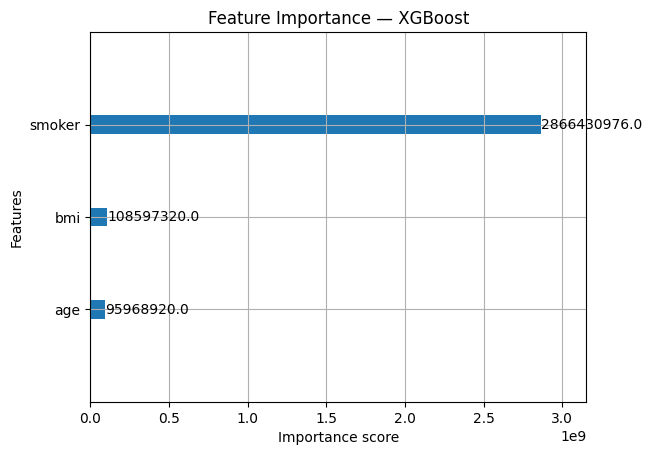

In [30]:
# Gráfica de importancia de features
IMAGES_PATH = Path("../../images")
IMAGES_PATH.mkdir(exist_ok=True)

plt.figure(figsize=(8, 4))
plot_importance(model_tuned2, importance_type='gain')
plt.title('Feature Importance — XGBoost')
plt.savefig(IMAGES_PATH / "09_feature_importance.png", dpi=100, bbox_inches='tight')
plt.show()

### 7.2 Explicabilidad del Modelo: SHAP Values

**SHAP (SHapley Additive exPlanations)** es una técnica basada en teoría de juegos que explica cómo cada variable contribuye a la predicción final. A diferencia de feature importance que mide importancia global, SHAP mide el impacto de cada variable **para cada predicción individual**.

**Interpretación:**
- **Eje X:** Valor SHAP (impacto en la predicción)
- **Color rojo:** Variable aumenta la predicción de costo
- **Color azul:** Variable disminuye la predicción de costo
- **Scatter plot:** Distribución del impacto para todos los ejemplos

El gráfico global muestra el impacto promedio de cada variable sobre el modelo, permitiendo identificar:
- Qué variables tienen mayor poder explicativo
- En qué dirección influyen en el costo predicho
- La variabilidad de su impacto

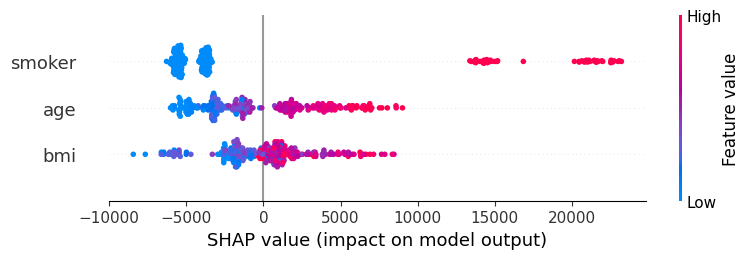

<Figure size 640x480 with 0 Axes>

In [31]:
# Crear el explicador SHAP para el modelo XGBoost
explainer = shap.TreeExplainer(model_tuned2)

# Calcular los valores SHAP para el test set
shap_values = explainer.shap_values(x_test)

# Visualización global — impacto promedio de cada variable
shap.summary_plot(shap_values, x_test)
plt.savefig(IMAGES_PATH / "10_shap_values.png", dpi=100, bbox_inches='tight')

## 8. Validación Cruzada (Cross-Validation)

El split 80/20 utilizado anteriormente es **simple pero riesgoso**: un único test set puede ser afortunado o desafortunado. La **validación cruzada (k-fold)** evalúa el modelo en múltiples subconjuntos del dataset para obtener una estimación más robusta del error real.

**K-Fold Cross-Validation con k=5:**
- Divide el dataset en 5 folds (subconjuntos) de tamaño similar
- Entrena 5 modelos: 4 folds para entrenamiento, 1 para validación (rotativo)
- Calcula la métrica (R² en este caso) para cada fold
- Reporta promedio y desviación estándar

**Interpretación:**
- **Promedio:** Rendimiento esperado del modelo en datos nuevos
- **Desviación estándar:** Variabilidad del rendimiento (baja = consistencia)

In [28]:
# Modelo final que ya tenemos
model_cv = XGBRegressor(
    n_estimators=1000,
    max_depth=5,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# K-Fold con 5 folds — scoring='r2' evalúa R² en cada fold
scores = cross_val_score(model_cv, x, y, cv=5, scoring='r2')

print(f"R² por fold:  {scores.round(4)}")
print(f"R² promedio:  {scores.mean():.4f}")
print(f"Desviación:   {scores.std():.4f}")

R² por fold:  [0.8579 0.778  0.864  0.8263 0.8398]
R² promedio:  0.8332
Desviación:   0.0306
